# OncoBridge — Data Processing Notebook v5
## GDSC2 · Raw SMILES · Three Evaluation Splits · Scaffold Drug-Cold Split · Morgan FP Pre-computation

### What's new in v5 vs v4:
| Change | Description |
|--------|-------------|
| **Scaffold drug-cold split** | Cell 13 SPLIT 3 now uses Bemis-Murcko scaffold clustering via RDKit. Entire scaffold clusters are held out for test, guaranteeing the test drugs are structurally novel — not just randomly withheld instances of training chemistry. |
| **Morgan FP pre-computation** | New Cell 16 pre-computes ECFP4 Morgan fingerprints (radius=2, 1024 bits) for all valid drugs using `rdFingerprintGenerator` (new RDKit API, no deprecation warnings) and saves `drug_morgan_fps.npy` + `drug_morgan_fp_order.json`. Notebook 2 can load with a single `np.load` call instead of computing per-batch. |
| **rdkit install guard** | Cell 1 checks for rdkit before installing to handle both Kaggle (pre-installed) and other envs. |

### What carries over from v4:
| | |
|--|--|
| **GDSC2-only** | `USE_GDSC1 = False` — fair comparison vs literature |
| **Raw SMILES** | PubChem fetch → canonical SMILES saved as CSV (ChemBERTa path unchanged) |
| **Methylation fix** | Gene column preserved; TSS→gene→TCGA overlap correct; 0.5 neutral fill |
| **Three splits** | Warm-start (80/10/10), Cell-Cold-Start (20% cells held out), Drug-Cold-Start (15% drugs held out) |
| **LN(IC50)** | log2 × ln(2) conversion |
| **Scaler fit on cl_cell_train** | Zero test leakage — scaler is fit only on cell-cold train cell lines |


In [1]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 1 — INSTALLS  (run once; Kaggle caches pip packages)
#
#  v5 change: added rdkit guard.
#  rdkit is pre-installed on Kaggle; the try/except avoids a redundant
#  pip call there while still installing it in other environments.
# ═══════════════════════════════════════════════════════════════════════
import subprocess, sys

def pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *pkgs], check=True)

pip('pubchempy', 'pyarrow', 'fastparquet')
print('✓ pubchempy  ✓ pyarrow  ✓ fastparquet installed.')

# rdkit is pre-installed on Kaggle — install as fallback for other envs
try:
    from rdkit import Chem
    print('✓ rdkit already available.')
except ImportError:
    pip('rdkit')
    print('✓ rdkit installed.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 20.3 MB/s eta 0:00:00
✓ pubchempy  ✓ pyarrow  ✓ fastparquet installed.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 45.1 MB/s eta 0:00:00
✓ rdkit installed.


In [2]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 2 — IMPORTS & HELPERS
# ═══════════════════════════════════════════════════════════════════════
import os, re, gc, json, time, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.preprocessing import LabelEncoder

import pubchempy as pcp

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.size']         = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')

def section(t):
    print('\n' + '═'*70)
    print(f'  {t}')
    print('═'*70)

def mem_usage(df, name):
    mb = df.memory_usage(deep=True).sum() / 1e6
    print(f'  [{name}] RAM: {mb:.1f} MB | shape: {df.shape}')

print('Imports OK.')


Imports OK.


In [3]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 3 — CONFIG  ← edit paths and flags here
#  NOTE: USE_GDSC1 is intentionally False — we use GDSC2 only.
#  Variable names still reference "gdsc1" in paths because that's how
#  the Kaggle dataset is named; the data itself is GDSC2.
# ═══════════════════════════════════════════════════════════════════════

CFG = dict(
    # ── Dataset toggle ──────────────────────────────────────────────────
    USE_GDSC1 = False,   # False = GDSC2 only (fair comparison vs literature)

    # ── IC50 scale ──────────────────────────────────────────────────────
    IC50_SCALE = 'ln',   # 'ln' = multiply log2 by ln(2) — correct for RMSE

    # ── Drug / cell line filters ────────────────────────────────────────
    MIN_SAMPLES_PER_DRUG     = 50,
    MIN_SAMPLES_PER_CELLLINE = 10,

    # ── Split fractions ──────────────────────────────────────────────────
    WARM_VAL_FRAC      = 0.10,    # warm-start: 80/10/10
    WARM_TEST_FRAC     = 0.10,
    CELL_COLD_FRAC     = 0.20,    # cell-cold-start: 20% cell lines held out
    DRUG_COLD_FRAC     = 0.15,    # drug-cold-start: ~15% drugs held out (scaffold clusters)
    SEED               = 42,

    # ── Gene dims — must match TCGA Phase 1 training ─────────────────────
    N_MRNA  = 8011,
    N_CNV   = 3500,
    N_MUT   = 2500,
    N_METH  = 6000,

    # ── Morgan fingerprint config (Cell 16) ─────────────────────────────
    FP_RADIUS = 2,       # ECFP4
    FP_NBITS  = 1024,

    # ── Paths ─────────────────────────────────────────────────────────────
    BASE         = '/kaggle/input/datasets/proutkarshtiwari/drug-cell-line-data-phase-2',
    SANGER_CSV   = 'sanger-dose-response.csv',
    MODEL_CSV    = 'Model.csv',
    MRNA_CSV     = 'OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv',
    CNV_CSV      = 'OmicsCNGeneWGS.csv',
    MUT_CSV      = 'OmicsSomaticMutationsMatrixDamaging.csv',
    METH_CSV     = 'CCLE_RRBS_TSS_1kb_20180614.txt',
    GENE_JSON    = '/kaggle/input/datasets/proutkarshtiwari/drug-cell-line-data-phase-2/selected_genes.json',
    SMILES_CACHE = '/kaggle/working/drug_smiles_cache.csv',
    OUT_DIR      = '/kaggle/working/',
)

DATASETS = ['GDSC1', 'GDSC2'] if CFG['USE_GDSC1'] else ['GDSC2']
print(f'USE_GDSC1     = {CFG["USE_GDSC1"]}  →  Datasets filtered: {DATASETS}')
print(f'IC50_SCALE    = {CFG["IC50_SCALE"]}')
print(f'Cell-cold frac: {CFG["CELL_COLD_FRAC"]*100:.0f}%  |  Drug-cold frac: ~{CFG["DRUG_COLD_FRAC"]*100:.0f}% (scaffold-based)')
print(f'Warm split: {int((1-CFG["WARM_VAL_FRAC"]-CFG["WARM_TEST_FRAC"])*100)}/{int(CFG["WARM_VAL_FRAC"]*100)}/{int(CFG["WARM_TEST_FRAC"]*100)} (train/val/test)')
print(f'Morgan FP: radius={CFG["FP_RADIUS"]} (ECFP4), {CFG["FP_NBITS"]} bits')


USE_GDSC1     = False  →  Datasets filtered: ['GDSC2']
IC50_SCALE    = ln
Cell-cold frac: 20%  |  Drug-cold frac: ~15% (scaffold-based)
Warm split: 80/10/10 (train/val/test)
Morgan FP: radius=2 (ECFP4), 1024 bits


In [4]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 4 — LOAD TCGA GENE LISTS (Phase 1 anchor)
#  These are the EXACT gene lists the backbone was pre-trained on.
#  We MUST align CCLE features to this space — no extra features allowed.
# ═══════════════════════════════════════════════════════════════════════
section('4. TCGA GENE LISTS')

with open(CFG['GENE_JSON']) as f:
    gene_names = json.load(f)

GENES = {
    'mrna': gene_names['mrna'],   # 8011 genes
    'cnv':  gene_names['cnv'],    # 3500 genes
    'mut':  gene_names['mut'],    # 2500 genes
    'meth': gene_names['meth'],   # 6000 genes — methylation beta values
}

print('Gene counts from Phase 1 training (TCGA):')
for k, v in GENES.items():
    print(f'  {k:>4}: {len(v):>6,} genes')
print(f'  Total features: {sum(len(v) for v in GENES.values()):,}')



══════════════════════════════════════════════════════════════════════
  4. TCGA GENE LISTS
══════════════════════════════════════════════════════════════════════
Gene counts from Phase 1 training (TCGA):
  mrna:  8,011 genes
   cnv:  3,500 genes
   mut:  2,500 genes
  meth:  6,000 genes
  Total features: 20,011



══════════════════════════════════════════════════════════════════════
  5. SANGER IC50 LABELS
══════════════════════════════════════════════════════════════════════
Raw shape: (387626, 20)
Datasets in file: ['GDSC1' 'GDSC2']
After dataset filter (['GDSC2']): 118,908 rows
Converted log2(IC50) → ln(IC50) [×0.6931]
IC50 stats: mean=-0.298  std=2.550  range=[-8.63, 4.60]
After deduplication: 23,739 rows
After drug filter (≥50 samples): 22,823 rows | 86 drugs
After cell line filter (≥10 drugs): 22,239 rows

Final: 22,239 IC50 pairs | 86 drugs | 703 cell lines
Elapsed: 2.5s


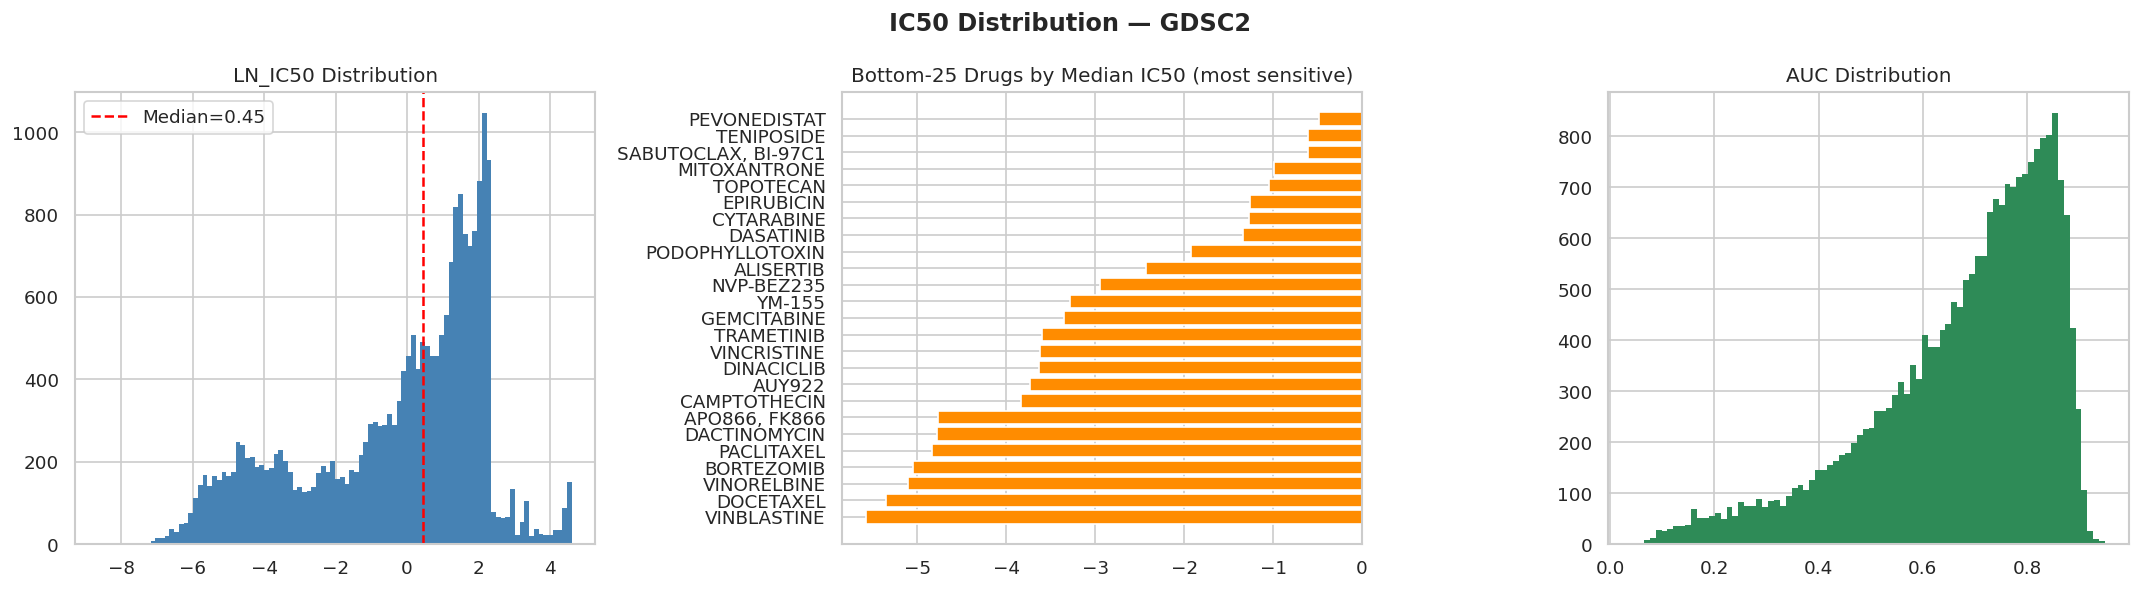

In [5]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 5 — SANGER IC50 LABELS
#  Source: sanger-dose-response.csv
#  We convert log2(IC50) → ln(IC50) by multiplying by ln(2) ≈ 0.6931.
#  This ensures RMSE is comparable to literature values reported in ln space.
# ═══════════════════════════════════════════════════════════════════════
section('5. SANGER IC50 LABELS')

t0 = time.time()
raw = pd.read_csv(f"{CFG['BASE']}/{CFG['SANGER_CSV']}", low_memory=False)
print(f'Raw shape: {raw.shape}')
print(f'Datasets in file: {raw["DATASET"].unique()}')

# ── Filter to GDSC2 only ─────────────────────────────────────────────────
ic50 = raw[raw['DATASET'].isin(DATASETS)].copy()
print(f'After dataset filter ({DATASETS}): {len(ic50):,} rows')

# ── Drop missing IC50 ───────────────────────────────────────────────────
ic50 = ic50.dropna(subset=['log2.ic50'])

# ── Convert log2(IC50) → ln(IC50) ──────────────────────────────────────
LN2 = np.log(2)   # ≈ 0.6931
ic50['ic50_value'] = ic50['log2.ic50'] * LN2
print(f'Converted log2(IC50) → ln(IC50) [×{LN2:.4f}]')
print(f'IC50 stats: mean={ic50["ic50_value"].mean():.3f}  '
      f'std={ic50["ic50_value"].std():.3f}  '
      f'range=[{ic50["ic50_value"].min():.2f}, {ic50["ic50_value"].max():.2f}]')

# ── Deduplicate (for GDSC2-only this is a no-op, but kept for safety) ────
ic50 = ic50.drop_duplicates(subset=['COSMIC_ID', 'DRUG_NAME'], keep='first')
print(f'After deduplication: {len(ic50):,} rows')

# ── Drug coverage filter ─────────────────────────────────────────────────
drug_counts = ic50['DRUG_NAME'].value_counts()
valid_drugs = drug_counts[drug_counts >= CFG['MIN_SAMPLES_PER_DRUG']].index
ic50 = ic50[ic50['DRUG_NAME'].isin(valid_drugs)]
print(f'After drug filter (≥{CFG["MIN_SAMPLES_PER_DRUG"]} samples): '
      f'{len(ic50):,} rows | {ic50["DRUG_NAME"].nunique()} drugs')

# ── Cell line filter ─────────────────────────────────────────────────────
cl_counts = ic50.groupby('COSMIC_ID').size()
valid_cls  = cl_counts[cl_counts >= CFG['MIN_SAMPLES_PER_CELLLINE']].index
ic50 = ic50[ic50['COSMIC_ID'].isin(valid_cls)]
print(f'After cell line filter (≥{CFG["MIN_SAMPLES_PER_CELLLINE"]} drugs): '
      f'{len(ic50):,} rows')

# ── Finalise columns ─────────────────────────────────────────────────────
ic50 = ic50[['COSMIC_ID','DRUG_NAME','DATASET','ic50_value',
             'AUC_PUBLISHED','Z_SCORE_PUBLISHED']].copy()
ic50 = ic50.rename(columns={'AUC_PUBLISHED':'AUC','Z_SCORE_PUBLISHED':'Z_SCORE'})
ic50['COSMIC_ID'] = ic50['COSMIC_ID'].astype(int)

DRUG_NAMES = sorted(ic50['DRUG_NAME'].unique())
print(f'\nFinal: {len(ic50):,} IC50 pairs | {ic50["DRUG_NAME"].nunique()} drugs | '
      f'{ic50["COSMIC_ID"].nunique()} cell lines')
print(f'Elapsed: {time.time()-t0:.1f}s')
del raw; gc.collect()

# ── EDA ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'IC50 Distribution — GDSC2', fontweight='bold')
axes[0].hist(ic50['ic50_value'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('LN_IC50 Distribution')
axes[0].axvline(ic50['ic50_value'].median(), color='red', ls='--',
                label=f'Median={ic50["ic50_value"].median():.2f}')
axes[0].legend()
drug_med = ic50.groupby('DRUG_NAME')['ic50_value'].median().sort_values().head(25)
axes[1].barh(drug_med.index, drug_med.values, color='darkorange')
axes[1].set_title('Bottom-25 Drugs by Median IC50 (most sensitive)')
axes[2].hist(ic50['AUC'].dropna(), bins=80, color='seagreen', edgecolor='none')
axes[2].set_title('AUC Distribution')
plt.tight_layout(); plt.show()


In [6]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 6 — FETCH & SAVE RAW CANONICAL SMILES FROM PUBCHEM
#
#  KEY CHANGE from v3: We NO LONGER compute Morgan Fingerprints here.
#  Instead we save raw canonical SMILES strings to CSV.
#  ChemBERTa (Notebook 2) will tokenize these on-the-fly.
#
#  Morgan fingerprints are now pre-computed separately in Cell 16.
#
#  Rationale: ChemBERTa was pre-trained on SMILES strings, not binary FPs.
#  Feeding raw SMILES preserves the full chemical language context,
#  enabling better transfer learning from ChemBERTa's pre-training.
# ═══════════════════════════════════════════════════════════════════════
section('6. FETCH RAW CANONICAL SMILES FROM PUBCHEM')

def clean_name(name):
    """Extract primary drug name from GDSC alias strings like 'Drug A; Drug B'."""   
    primary = name.split(';')[0].strip()
    primary = re.sub(r'\s*\(.*?\)', '', primary).strip()
    return primary

def fetch_smiles_pubchem(name, timeout=15):
    """Query PubChem by name, return canonical SMILES or None."""
    try:
        res = pcp.get_compounds(name, 'name', timeout=timeout)
        if res:
            smiles = res[0].canonical_smiles or res[0].isomeric_smiles
            if smiles:
                return smiles
    except Exception:
        pass
    return None

def load_or_fetch_smiles_cache(drug_names, cache_path, sleep_sec=0.4):
    """
    Load SMILES from disk cache if available, otherwise fetch from PubChem.
    Cache is a simple CSV: drug_name, canonical_smiles.
    Returns dict: {drug_name: smiles_string_or_None}
    """
    cache_path = Path(cache_path)
    cache = {}

    if cache_path.exists():
        df_c = pd.read_csv(cache_path)
        cache = {
            r['drug_name']: (None if pd.isna(r['canonical_smiles']) else r['canonical_smiles'])
            for _, r in df_c.iterrows()
        }
        print(f'  Loaded {len(cache)} cached SMILES entries from {cache_path.name}')

    missing = [d for d in drug_names if d not in cache]
    print(f'  Drugs to fetch from PubChem: {len(missing)}')

    for i, name in enumerate(missing):
        smiles = fetch_smiles_pubchem(clean_name(name))

        if smiles is None and ';' in name:
            for alias in name.split(';'):
                smiles = fetch_smiles_pubchem(alias.strip())
                if smiles:
                    break

        cache[name] = smiles
        status = 'OK ✓' if smiles else 'MISSING ✗'

        if (i + 1) % 10 == 0 or i == len(missing) - 1:
            print(f'  [{i+1:>3}/{len(missing)}] {name[:55]:<55}  {status}')
            time.sleep(sleep_sec)

    pd.DataFrame(
        [(k, v) for k, v in cache.items()],
        columns=['drug_name', 'canonical_smiles']
    ).to_csv(cache_path, index=False)
    print(f'  Cache saved → {cache_path}')

    return cache


print(f'Fetching canonical SMILES for {len(DRUG_NAMES)} GDSC2 drugs...')
print('This will be cached to disk — only slow on first run.\n')
smiles_map = load_or_fetch_smiles_cache(DRUG_NAMES, CFG['SMILES_CACHE'])

n_ok   = sum(1 for v in smiles_map.values() if v is not None)
n_miss = len(smiles_map) - n_ok
print(f'\nSMILES coverage:')
print(f'  Found:   {n_ok}/{len(smiles_map)} drugs ({n_ok/len(smiles_map)*100:.1f}%)')
print(f'  Missing: {n_miss} drugs (will be excluded from training)')

if n_miss > 0:
    missing_list = [d for d, s in smiles_map.items() if s is None]
    print(f'  Missing drug names: {missing_list[:10]}')

VALID_DRUG_NAMES = sorted([d for d, s in smiles_map.items() if s is not None])
before = len(ic50)
ic50 = ic50[ic50['DRUG_NAME'].isin(VALID_DRUG_NAMES)].copy()
print(f'\nIC50 rows after SMILES filter: {before:,} → {len(ic50):,}')
print(f'Final drug count: {len(VALID_DRUG_NAMES)}')

smiles_df = pd.DataFrame(
    [(d, smiles_map[d]) for d in VALID_DRUG_NAMES],
    columns=['drug_name', 'canonical_smiles']
)
smiles_df.to_csv(f"{CFG['OUT_DIR']}/drug_canonical_smiles.csv", index=False)
print(f'\nSaved: drug_canonical_smiles.csv  (shape: {smiles_df.shape})')
print('Sample SMILES:')
print(smiles_df.head(5).to_string(index=False))



══════════════════════════════════════════════════════════════════════
  6. FETCH RAW CANONICAL SMILES FROM PUBCHEM
══════════════════════════════════════════════════════════════════════
Fetching canonical SMILES for 86 GDSC2 drugs...
This will be cached to disk — only slow on first run.

  Drugs to fetch from PubChem: 86
  [ 10/86] AUY922                                                   OK ✓
  [ 20/86] BORTEZOMIB                                               OK ✓
  [ 30/86] DINACICLIB                                               OK ✓
  [ 40/86] GSK2110183                                               OK ✓
  [ 50/86] MK-8776, SCH900776                                       MISSING ✗
  [ 60/86] PACLITAXEL                                               OK ✓
  [ 70/86] TELOMERASE INHIBITOR IX, MST-312, MST 312, MST312        MISSING ✗
  [ 80/86] VINORELBINE                                              OK ✓
  [ 86/86] YM-155                                                   OK ✓
  Cache 

In [7]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 7 — MODEL.CSV — CELL LINE METADATA & ID MAPPING
# ═══════════════════════════════════════════════════════════════════════
section('7. MODEL.CSV — ID MAPPING')

model_df = pd.read_csv(f"{CFG['BASE']}/{CFG['MODEL_CSV']}")
model_df = model_df[['ModelID','CellLineName','COSMICID',
                      'OncotreePrimaryDisease','OncotreeLineage',
                      'OncotreeSubtype','CCLEName']].copy()
model_df = model_df.dropna(subset=['COSMICID'])
model_df['COSMICID'] = model_df['COSMICID'].astype(int)
print(f'Model.csv: {len(model_df)} rows | {model_df["COSMICID"].nunique()} unique COSMICs')

ic50 = ic50.merge(model_df, left_on='COSMIC_ID', right_on='COSMICID', how='inner')
print(f'After join: {len(ic50):,} IC50 pairs')
print(f'Unique cell lines: {ic50["ModelID"].nunique()}')
print(f'Unique cancer types: {ic50["OncotreePrimaryDisease"].nunique()}')

drug2idx   = {d: i for i, d in enumerate(VALID_DRUG_NAMES)}
id_to_drug = {i: d for d, i in drug2idx.items()}
ic50['drug_idx'] = ic50['DRUG_NAME'].map(drug2idx)

valid_model_ids = set(ic50['ModelID'].unique())
print(f'Valid ModelIDs: {len(valid_model_ids)}')



══════════════════════════════════════════════════════════════════════
  7. MODEL.CSV — ID MAPPING
══════════════════════════════════════════════════════════════════════
Model.csv: 977 rows | 977 unique COSMICs
After join: 18,498 IC50 pairs
Unique cell lines: 684
Unique cancer types: 65
Valid ModelIDs: 684


In [8]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 8 — CCLE mRNA EXPRESSION
# ═══════════════════════════════════════════════════════════════════════
section('8. CCLE mRNA')

mrna_raw = pd.read_csv(f"{CFG['BASE']}/{CFG['MRNA_CSV']}", index_col=0, low_memory=False)
print(f'Raw shape: {mrna_raw.shape}')

if 'IsDefaultEntryForModel' in mrna_raw.columns:
    mrna_raw = mrna_raw[mrna_raw['IsDefaultEntryForModel'] == 'Yes'].copy()
    mrna_raw = mrna_raw.set_index('ModelID')
    mrna_raw = mrna_raw.drop(columns=['SequencingID','ModelConditionID',
                                       'IsDefaultEntryForMC','IsDefaultEntryForModel'],
                               errors='ignore')

mrna_raw.columns = [str(c).split(' (')[0].strip() for c in mrna_raw.columns]
mrna_raw = mrna_raw.loc[:, ~mrna_raw.columns.duplicated(keep='first')]
mrna_raw = mrna_raw[mrna_raw.index.isin(valid_model_ids)]

overlap_m = set(mrna_raw.columns) & set(GENES['mrna'])
print(f'mRNA overlap with TCGA genes: {len(overlap_m)}/{len(GENES["mrna"])}')

mrna_df = mrna_raw.reindex(columns=GENES['mrna'], fill_value=0.0).fillna(0.0).astype(np.float32)
print(f'Final mRNA: {mrna_df.shape}')
valid_model_ids_mrna = set(mrna_df.index)
del mrna_raw; gc.collect()
mem_usage(mrna_df, 'mRNA')



══════════════════════════════════════════════════════════════════════
  8. CCLE mRNA
══════════════════════════════════════════════════════════════════════
Raw shape: (1775, 19220)
mRNA overlap with TCGA genes: 7374/8011
Final mRNA: (532, 8011)
  [mRNA] RAM: 17.1 MB | shape: (532, 8011)


In [9]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 9 — CCLE CNV
# ═══════════════════════════════════════════════════════════════════════
section('9. CCLE CNV')

cnv_raw = pd.read_csv(f"{CFG['BASE']}/{CFG['CNV_CSV']}", index_col=0, low_memory=False)
if 'IsDefaultEntryForModel' in cnv_raw.columns:
    cnv_raw = cnv_raw[cnv_raw['IsDefaultEntryForModel'] == 'Yes'].copy()
    cnv_raw = cnv_raw.set_index('ModelID')
    cnv_raw = cnv_raw.drop(columns=['SequencingID','ModelConditionID',
                                     'IsDefaultEntryForMC','IsDefaultEntryForModel'],
                            errors='ignore')

cnv_raw.columns = [str(c).split(' (')[0].strip() for c in cnv_raw.columns]
cnv_raw = cnv_raw.loc[:, ~cnv_raw.columns.duplicated(keep='first')]
cnv_raw = cnv_raw[cnv_raw.index.isin(valid_model_ids)]
cnv_raw = cnv_raw.fillna(2.0).clip(lower=0.01)
cnv_raw = np.log2(cnv_raw / 2.0).astype(np.float32)

overlap_c = set(cnv_raw.columns) & set(GENES['cnv'])
print(f'CNV overlap with TCGA genes: {len(overlap_c)}/{len(GENES["cnv"])}')

cnv_df = cnv_raw.reindex(columns=GENES['cnv'], fill_value=0.0).astype(np.float32)
print(f'Final CNV: {cnv_df.shape}')
valid_model_ids_cnv = set(cnv_df.index)
del cnv_raw; gc.collect()
mem_usage(cnv_df, 'CNV')



══════════════════════════════════════════════════════════════════════
  9. CCLE CNV
══════════════════════════════════════════════════════════════════════
CNV overlap with TCGA genes: 3232/3500
Final CNV: (389, 3500)
  [CNV] RAM: 5.5 MB | shape: (389, 3500)


In [10]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 10 — CCLE MUTATION
# ═══════════════════════════════════════════════════════════════════════
section('10. CCLE MUTATION')

mut_raw = pd.read_csv(f"{CFG['BASE']}/{CFG['MUT_CSV']}", index_col=0, low_memory=False)
if 'IsDefaultEntryForModel' in mut_raw.columns:
    mut_raw = mut_raw[mut_raw['IsDefaultEntryForModel'] == 'Yes'].copy()
    mut_raw = mut_raw.set_index('ModelID')
    mut_raw = mut_raw.drop(columns=['SequencingID','ModelConditionID',
                                     'IsDefaultEntryForMC','IsDefaultEntryForModel'],
                            errors='ignore')

mut_raw.columns = [str(c).split(' (')[0].strip() for c in mut_raw.columns]
mut_raw = mut_raw.loc[:, ~mut_raw.columns.duplicated(keep='first')]
mut_raw = mut_raw[mut_raw.index.isin(valid_model_ids)]
mut_raw = mut_raw.fillna(0).clip(0, 1).round(0).astype(np.int8)

overlap_u = set(mut_raw.columns) & set(GENES['mut'])
sparsity  = (mut_raw == 0).values.mean()
print(f'Mutation overlap with TCGA genes: {len(overlap_u)}/{len(GENES["mut"])}')
print(f'Sparsity (wildtype fraction): {sparsity*100:.1f}%')

mut_df = mut_raw.reindex(columns=GENES['mut'], fill_value=0).astype(np.float32)
print(f'Final Mutation: {mut_df.shape}')
valid_model_ids_mut = set(mut_df.index)
del mut_raw; gc.collect()
mem_usage(mut_df, 'Mutation')



══════════════════════════════════════════════════════════════════════
  10. CCLE MUTATION
══════════════════════════════════════════════════════════════════════
Mutation overlap with TCGA genes: 2380/2500
Sparsity (wildtype fraction): 99.6%
Final Mutation: (675, 2500)
  [Mutation] RAM: 6.8 MB | shape: (675, 2500)



══════════════════════════════════════════════════════════════════════
  11. CCLE METHYLATION (RRBS) — ROBUST GENE OVERLAP
══════════════════════════════════════════════════════════════════════
Loading CCLE_RRBS_TSS_1kb_20180614.txt...
Raw shape: (20192, 850)
Column names [0:8]: ['TSS_id', 'gene', 'chr', 'fpos', 'tpos', 'strand', 'avg_coverage', 'DMS53_LUNG']
Gene column found. Sample values: ['LOC100288069' 'LINC01128' 'LINC01128' 'LOC100130417' 'SAMD11']

After dropping metadata: (20192, 844)
TSS aggregation: 20,192 TSS → 16,494 unique genes
After transpose: (844, 16494)
Mapped CCLEName → ModelID: 844 → 839 cell lines
Filtered to cell lines with GDSC2 IC50: 839 → 417
Missing values: 275,038 → 0

Gene space alignment (Methylation):
  TCGA selected genes:   6,000
  CCLE RRBS genes:       16,494
  Overlap:               3,205  (53.4%)
  Missing in CCLE→0.5:   2,795

Final Methylation shape: (417, 6000)


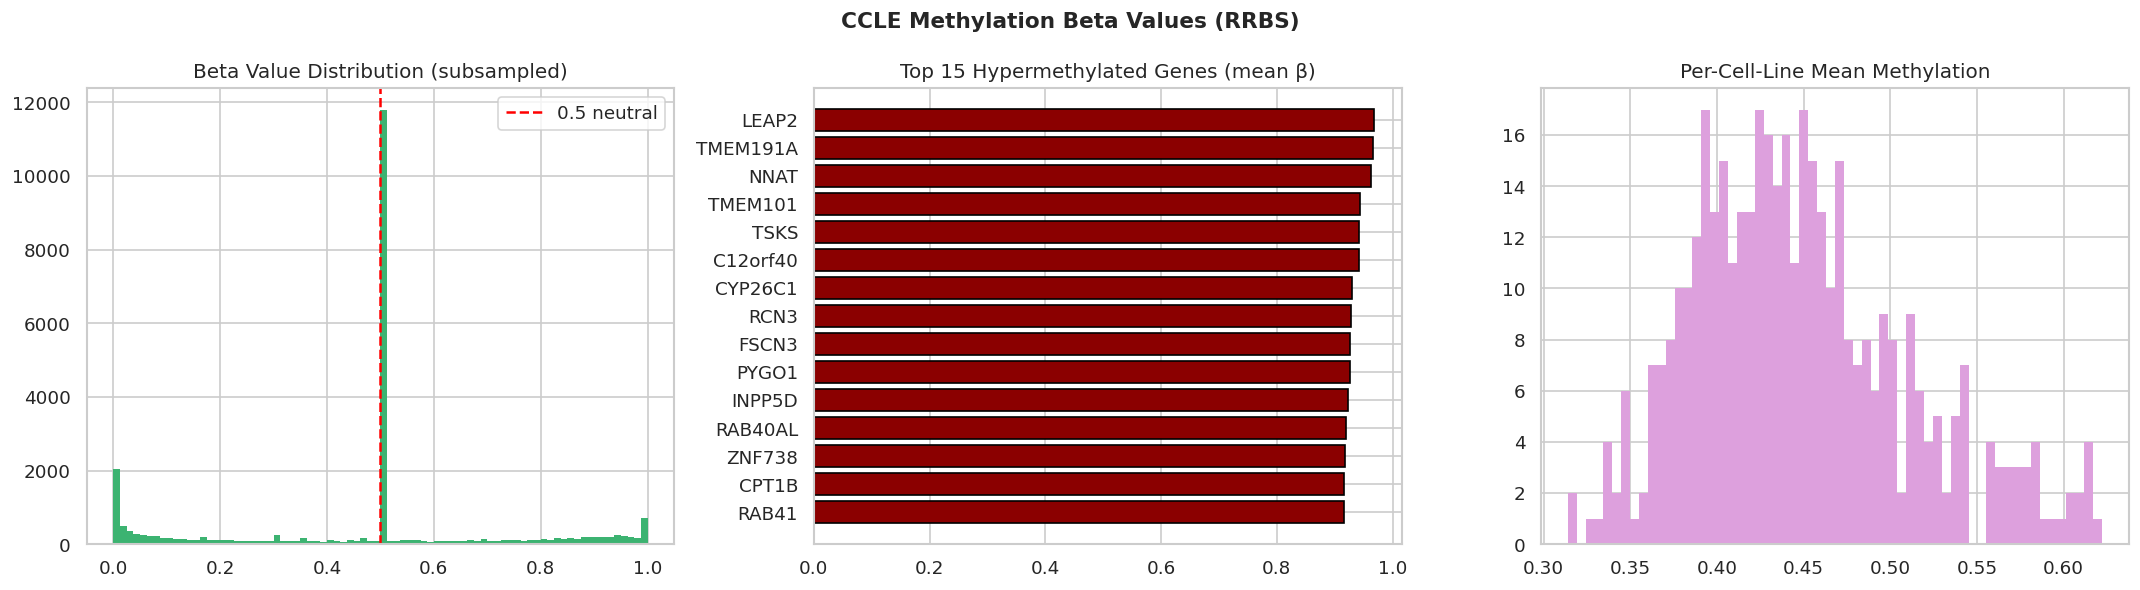

  [Methylation filtered] RAM: 10.0 MB | shape: (417, 6000)
Cell lines with Methylation data: 417


In [11]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 11 — CCLE METHYLATION (RRBS) — ROBUST IMPLEMENTATION
# ═══════════════════════════════════════════════════════════════════════
section('11. CCLE METHYLATION (RRBS) — ROBUST GENE OVERLAP')

print('Loading CCLE_RRBS_TSS_1kb_20180614.txt...')
meth_raw = pd.read_csv(f"{CFG['BASE']}/{CFG['METH_CSV']}", sep='\t', low_memory=False)
print(f'Raw shape: {meth_raw.shape}')
print(f'Column names [0:8]: {meth_raw.columns.tolist()[:8]}')

if 'gene' in meth_raw.columns:
    gene_col_values = meth_raw['gene'].values
    print(f'Gene column found. Sample values: {gene_col_values[:5]}')
else:
    gene_col_values = meth_raw.iloc[:, 0].values
    print(f'Using first column as gene names. Sample: {gene_col_values[:5]}')

meta_cols = ['gene', 'chr', 'fpos', 'tpos', 'strand', 'avg_coverage']
meth_data  = meth_raw.drop(columns=meta_cols, errors='ignore')
print(f'\nAfter dropping metadata: {meth_data.shape}')

meth_data = meth_data.apply(pd.to_numeric, errors='coerce').astype(np.float32)
meth_data.index = gene_col_values

n_tss_before = len(meth_data)
meth_data     = meth_data.groupby(meth_data.index).mean()
print(f'TSS aggregation: {n_tss_before:,} TSS → {len(meth_data):,} unique genes')

meth_data = meth_data.T
print(f'After transpose: {meth_data.shape}')

model_map = pd.read_csv(f"{CFG['BASE']}/{CFG['MODEL_CSV']}", usecols=['ModelID', 'CCLEName'])
model_map = model_map.dropna(subset=['CCLEName'])
ccle_to_model = dict(zip(model_map['CCLEName'], model_map['ModelID']))

n_before_map = len(meth_data)
meth_data.index = meth_data.index.map(lambda x: ccle_to_model.get(x, None))
meth_data = meth_data[meth_data.index.notna()].copy()
meth_data.index = meth_data.index.astype(str)
print(f'Mapped CCLEName → ModelID: {n_before_map:,} → {len(meth_data):,} cell lines')

n_before_filter = len(meth_data)
meth_data = meth_data[meth_data.index.isin(valid_model_ids)].copy()
print(f'Filtered to cell lines with GDSC2 IC50: {n_before_filter:,} → {len(meth_data):,}')

nan_before = meth_data.isnull().sum().sum()
gene_means_fill = meth_data.mean(axis=0)
meth_data = meth_data.fillna(gene_means_fill)
meth_data = meth_data.fillna(0.5)
meth_data = meth_data.clip(0.0, 1.0).astype(np.float32)
nan_after = meth_data.isnull().sum().sum()
print(f'Missing values: {nan_before:,} → {nan_after:,}')

ccle_meth_genes = set(meth_data.columns)
tcga_meth_genes = set(GENES['meth'])
overlap_e       = ccle_meth_genes & tcga_meth_genes
missing_in_ccle = tcga_meth_genes - ccle_meth_genes

print(f'\nGene space alignment (Methylation):')
print(f'  TCGA selected genes:   {len(GENES["meth"]):,}')
print(f'  CCLE RRBS genes:       {len(ccle_meth_genes):,}')
print(f'  Overlap:               {len(overlap_e):,}  ({len(overlap_e)/len(GENES["meth"])*100:.1f}%)')
print(f'  Missing in CCLE→0.5:   {len(missing_in_ccle):,}')

meth_df = meth_data.reindex(columns=GENES['meth'], fill_value=0.5).astype(np.float32)
print(f'\nFinal Methylation shape: {meth_df.shape}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CCLE Methylation Beta Values (RRBS)', fontsize=13, fontweight='bold')
flat_vals = meth_df.values.flatten()[::100]
axes[0].hist(flat_vals, bins=80, color='mediumseagreen', edgecolor='none')
axes[0].set_title('Beta Value Distribution (subsampled)')
axes[0].axvline(0.5, color='red', linestyle='--', label='0.5 neutral')
axes[0].legend()
gene_mean_meth = meth_df.mean(axis=0)
top_hyper = gene_mean_meth.nlargest(15)
axes[1].barh(top_hyper.index, top_hyper.values, color='darkred', edgecolor='black')
axes[1].set_title('Top 15 Hypermethylated Genes (mean β)')
axes[1].invert_yaxis()
sample_mean_meth = meth_df.mean(axis=1)
axes[2].hist(sample_mean_meth, bins=60, color='plum', edgecolor='none')
axes[2].set_title('Per-Cell-Line Mean Methylation')
plt.tight_layout(); plt.show()

valid_model_ids_meth = set(meth_df.index)
mem_usage(meth_df, 'Methylation filtered')
del meth_raw, meth_data, flat_vals, gene_mean_meth, sample_mean_meth
del model_map, ccle_to_model; gc.collect()
print(f'Cell lines with Methylation data: {len(valid_model_ids_meth):,}')


In [12]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 12 — MASTER ALIGNMENT
# ═══════════════════════════════════════════════════════════════════════
section('12. MASTER ALIGNMENT')

print('Cell lines per modality:')
print(f'  mRNA : {len(valid_model_ids_mrna):,}')
print(f'  CNV  : {len(valid_model_ids_cnv):,}')
print(f'  Mut  : {len(valid_model_ids_mut):,}')
print(f'  Meth : {len(valid_model_ids_meth):,}')

have_3    = valid_model_ids_mrna & valid_model_ids_cnv & valid_model_ids_mut
have_all4 = have_3 & valid_model_ids_meth
have_3_no_meth = have_3 - valid_model_ids_meth

print(f'\nAll 4 modalities:        {len(have_all4):,}')
print(f'mRNA+CNV+Mut only:       {len(have_3_no_meth):,}  (methylation will be imputed)')

if len(have_3_no_meth) > 0:
    imp_meth = pd.DataFrame(
        0.5,
        index=sorted(have_3_no_meth),
        columns=GENES['meth'],
        dtype=np.float32
    )
    meth_df = pd.concat([meth_df, imp_meth])
    print(f'Imputed {len(have_3_no_meth)} rows of methylation with 0.5')

common_final = sorted(have_all4 | have_3_no_meth)
print(f'\nFinal usable cell lines: {len(common_final)}')

mrna_df = mrna_df.loc[mrna_df.index.isin(common_final)].reindex(common_final)
cnv_df  = cnv_df.loc[cnv_df.index.isin(common_final)].reindex(common_final)
mut_df  = mut_df.loc[mut_df.index.isin(common_final)].reindex(common_final)
meth_df = meth_df.loc[meth_df.index.isin(common_final)].reindex(common_final)

assert (mrna_df.index == cnv_df.index).all(),  'mRNA/CNV index mismatch!'
assert (mrna_df.index == mut_df.index).all(),  'mRNA/Mut index mismatch!'
assert (mrna_df.index == meth_df.index).all(), 'mRNA/Meth index mismatch!'
print('All modalities aligned ✓')

ic50 = ic50[ic50['ModelID'].isin(common_final)].copy()
print(f'IC50 pairs after alignment: {len(ic50):,}')



══════════════════════════════════════════════════════════════════════
  12. MASTER ALIGNMENT
══════════════════════════════════════════════════════════════════════
Cell lines per modality:
  mRNA : 532
  CNV  : 389
  Mut  : 675
  Meth : 417

All 4 modalities:        311
mRNA+CNV+Mut only:       77  (methylation will be imputed)
Imputed 77 rows of methylation with 0.5

Final usable cell lines: 388
All modalities aligned ✓
IC50 pairs after alignment: 9,967


In [13]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 13 — GENERATE THREE EVALUATION SPLITS  ← MUST come BEFORE scaling
#
#  WHY THIS ORDER MATTERS:
#  The scaler (Cell 14) must be fit ONLY on training cell lines.
#  To know which cell lines are training, we must split first.
#
#  v5 change — SPLIT 3 (drug-cold) is now scaffold-based:
#  Bemis-Murcko scaffold clustering via RDKit ensures that entire
#  scaffold clusters are held out for test. This guarantees the test
#  drugs are structurally novel — not just randomly withheld instances
#  of the same chemistry that already appears in training.
#
#  cl_cell_train defined here is passed to Cell 14 for strict scaler fitting.
# ═══════════════════════════════════════════════════════════════════════
section('13. GENERATING THREE EVALUATION SPLITS')

from sklearn.model_selection import train_test_split
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
import joblib

np.random.seed(CFG['SEED'])

# ── Shared: cancer-type map for stratified splitting ──────────────────
all_cls_arr = np.array(common_final)

cl_cancer_type_map = (
    ic50.drop_duplicates('ModelID')
        .set_index('ModelID')['OncotreePrimaryDisease']
        .to_dict()
)
types_arr = np.array([cl_cancer_type_map.get(cl, 'Unknown') for cl in all_cls_arr])


def safe_stratify_encode(types):
    """
    Remap any class with fewer than 6 samples to the dominant class,
    then LabelEncode. This prevents StratifiedShuffleSplit from crashing
    when a class is too rare to appear in both train and test folds.
    """
    s = pd.Series(types)
    counts = s.value_counts()
    dominant = counts.index[0]
    safe = np.where(s.map(counts) < 6, dominant, types)
    le = LabelEncoder()
    return le.fit_transform(safe)


type_enc = safe_stratify_encode(types_arr)

# ══════════════════════════════════════════════════════════════════════
#  SPLIT 1 — WARM-START  (80 / 10 / 10 random IC50-pair split)
#
#  Pairs are split directly, so the same cell line CAN appear in
#  train and test — that is the definition of a warm-start evaluation.
# ══════════════════════════════════════════════════════════════════════
print('─' * 60)
print('SPLIT 1: WARM-START (80/10/10 random pair split)')
print('─' * 60)

tv_pairs, ic50_warm_te = train_test_split(
    ic50,
    test_size=CFG['WARM_TEST_FRAC'],
    random_state=CFG['SEED']
)
ic50_warm_tr, ic50_warm_vl = train_test_split(
    tv_pairs,
    # Rescale val fraction to the remaining 90 %
    test_size=CFG['WARM_VAL_FRAC'] / (1.0 - CFG['WARM_TEST_FRAC']),
    random_state=CFG['SEED']
)

print(f'  Train pairs: {len(ic50_warm_tr):>6,}  ({len(ic50_warm_tr)/len(ic50)*100:.1f}%)')
print(f'  Val   pairs: {len(ic50_warm_vl):>6,}  ({len(ic50_warm_vl)/len(ic50)*100:.1f}%)')
print(f'  Test  pairs: {len(ic50_warm_te):>6,}  ({len(ic50_warm_te)/len(ic50)*100:.1f}%)  ✓')

# ══════════════════════════════════════════════════════════════════════
#  SPLIT 2 — CELL-COLD-START  (20 % of cell lines held out for test)
#
#  Cell lines are split at the cell-line level, so NO cell line in the
#  test set was ever seen during training or validation.
#
#  cl_cell_train  ← exported to Cell 14 for strict scaler fitting.
# ══════════════════════════════════════════════════════════════════════
print('\n' + '─' * 60)
print('SPLIT 2: CELL-COLD-START (20% cell lines held out for test)')
print('─' * 60)

# Step 2a — hold out 20 % of cell lines for testing
sss_cell_outer = StratifiedShuffleSplit(
    n_splits=1,
    test_size=CFG['CELL_COLD_FRAC'],
    random_state=CFG['SEED'] + 1
)
cell_tv_idx, cell_te_idx = next(sss_cell_outer.split(all_cls_arr, type_enc))

cl_cell_trainval = list(all_cls_arr[cell_tv_idx])  # 80 % pool
cl_cell_test     = list(all_cls_arr[cell_te_idx])  # 20 % held out

# Step 2b — split the 80 % trainval pool → 90 % train / 10 % val (by cell line)
tv_arr      = np.array(cl_cell_trainval)
type_enc_tv = safe_stratify_encode(type_enc[cell_tv_idx])

sss_cell_inner = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.10,
    random_state=CFG['SEED']
)
tv_tr_idx, tv_vl_idx = next(sss_cell_inner.split(tv_arr, type_enc_tv))

cl_cell_train = list(tv_arr[tv_tr_idx])   # ← USED BY CELL 14 TO FIT SCALERS
cl_cell_val   = list(tv_arr[tv_vl_idx])

# Hard leakage assertions — these must never fire
assert not (set(cl_cell_train) & set(cl_cell_test)), \
    f'CRITICAL: {len(set(cl_cell_train) & set(cl_cell_test))} CELL COLD TRAIN/TEST LEAKAGE!'
assert not (set(cl_cell_val)   & set(cl_cell_test)), \
    'CRITICAL: CELL COLD VAL/TEST LEAKAGE!'
assert not (set(cl_cell_train) & set(cl_cell_val)),  \
    'CRITICAL: CELL COLD TRAIN/VAL OVERLAP!'

ic50_cc_tr = ic50[ic50['ModelID'].isin(cl_cell_train)].copy()
ic50_cc_vl = ic50[ic50['ModelID'].isin(cl_cell_val)].copy()
ic50_cc_te = ic50[ic50['ModelID'].isin(cl_cell_test)].copy()

print(f'  Train cell lines: {len(cl_cell_train):>4}  | pairs: {len(ic50_cc_tr):>6,}')
print(f'  Val   cell lines: {len(cl_cell_val):>4}  | pairs: {len(ic50_cc_vl):>6,}')
print(f'  Test  cell lines: {len(cl_cell_test):>4}  | pairs: {len(ic50_cc_te):>6,}  (completely unseen) ✓')
print(f'  Leakage assertions passed ✓')

# ══════════════════════════════════════════════════════════════════════
#  SPLIT 3 — DRUG-COLD-START  (scaffold-based, ~15 % drugs held out)
#
#  WHY SCAFFOLD-BASED AND NOT RANDOM?
#  Random drug splitting withholds instances of chemistry that is already
#  represented in training (e.g., two EGFR inhibitors that share the same
#  quinazoline scaffold). The split *looks* cold but it isn't — the model
#  has seen structurally identical drugs and can interpolate trivially.
#
#  Bemis-Murcko scaffold clustering ensures ENTIRE scaffold clusters are
#  held out. Every drug in the test set has a core ring system + linker
#  pattern that never appeared in training or validation, making this a
#  genuine test of extrapolation to new chemical space.
#
#  Algorithm:
#    1. Compute Bemis-Murcko scaffold SMILES for every valid drug.
#       Acyclic drugs (empty scaffold) each become their own singleton.
#    2. Cluster drugs that share an identical scaffold SMILES.
#    3. Sort clusters deterministically (size ASC, then scaffold ASC),
#       then shuffle the cluster order with a fixed seed.
#    4. Greedily add whole clusters to the test set until ≥ target count.
#       Adding whole clusters guarantees zero scaffold leakage.
#    5. Hard-assert that zero scaffold strings are shared between the
#       cold-test set and the warm-pool.
# ══════════════════════════════════════════════════════════════════════
print('\n' + '─' * 60)
print('SPLIT 3: DRUG-COLD-START (scaffold-based, ~15% drugs never seen)')
print('─' * 60)

# ── Helper ────────────────────────────────────────────────────────────
def get_murcko_scaffold(smiles):
    """
    Return canonical Bemis-Murcko scaffold SMILES for a drug.
    Returns None if the SMILES cannot be parsed by RDKit.
    An empty-string scaffold (acyclic/linear drug) is treated as None
    so acyclic drugs each become their own isolated singleton cluster.
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        scaffold_mol = MurckoScaffold.GetScaffoldForMol(mol)
        sc_smi = Chem.MolToSmiles(scaffold_mol, isomericSmiles=False)
        return sc_smi if sc_smi else None   # empty string → acyclic drug
    except Exception:
        return None

# ── Step 1: compute scaffold for every valid drug ─────────────────────
print('  Computing Bemis-Murcko scaffolds...')
drug_scaffold = {}
for drug in VALID_DRUG_NAMES:
    smiles = smiles_map.get(drug)
    if smiles:
        sc = get_murcko_scaffold(smiles)
        # Acyclic/unparseable drugs → unique pseudo-scaffold so they form
        # their own singleton cluster and are never grouped with ring drugs.
        drug_scaffold[drug] = sc if sc else f'__ACYCLIC__{drug}'
    else:
        drug_scaffold[drug] = f'__NO_SMILES__{drug}'

# ── Step 2: cluster by scaffold ───────────────────────────────────────
scaffold_to_drugs = defaultdict(list)
for drug, sc in drug_scaffold.items():
    scaffold_to_drugs[sc].append(drug)

n_unique_scaffolds = len(scaffold_to_drugs)
n_singletons       = sum(1 for v in scaffold_to_drugs.values() if len(v) == 1)
n_multi_clusters   = n_unique_scaffolds - n_singletons
print(f'  Drugs: {len(VALID_DRUG_NAMES)} | Unique scaffolds: {n_unique_scaffolds}')
print(f'  Multi-drug scaffold clusters: {n_multi_clusters} | Singletons: {n_singletons}')

# ── Step 3: deterministic sort → shuffle ─────────────────────────────
# Sort by (cluster_size ASC, scaffold_smi ASC) for full reproducibility
# before applying the random permutation.
scaffold_list = sorted(scaffold_to_drugs.items(), key=lambda x: (len(x[1]), x[0]))

target_n_cold = max(1, int(len(VALID_DRUG_NAMES) * CFG['DRUG_COLD_FRAC']))
rng           = np.random.default_rng(CFG['SEED'] + 2)
order         = rng.permutation(len(scaffold_list))

# ── Step 4: greedily add whole clusters until target is met ───────────
# We always complete the cluster in progress — never partially split one.
# The actual cold count may slightly exceed target_n_cold when the last
# added cluster has more than one drug; this is by design.
drug_cold_test = []
for idx in order:
    if len(drug_cold_test) >= target_n_cold:
        break
    _, drugs = scaffold_list[idx]
    drug_cold_test.extend(drugs)

drug_warm_pool   = [d for d in VALID_DRUG_NAMES if d not in set(drug_cold_test)]
actual_cold_frac = len(drug_cold_test) / len(VALID_DRUG_NAMES)

# ── Step 5: scaffold isolation assertion ─────────────────────────────
# Pseudo-scaffolds (__ACYCLIC__, __NO_SMILES__) are excluded from this
# check because they are unique by construction and cannot overlap.
cold_scaffolds   = {drug_scaffold[d] for d in drug_cold_test
                    if not drug_scaffold[d].startswith('__')}
warm_scaffolds   = {drug_scaffold[d] for d in drug_warm_pool
                    if not drug_scaffold[d].startswith('__')}
scaffold_overlap = cold_scaffolds & warm_scaffolds
assert len(scaffold_overlap) == 0, \
    f'CRITICAL: {len(scaffold_overlap)} scaffold(s) shared between cold-test and warm-pool!'
assert not (set(drug_warm_pool) & set(drug_cold_test)), \
    'CRITICAL: DRUG COLD DRUG-LEVEL LEAKAGE!'

# ── Step 6: build split dataframes ───────────────────────────────────
ic50_dc_te     = ic50[ic50['DRUG_NAME'].isin(drug_cold_test)].copy()
ic50_drug_warm = ic50[ic50['DRUG_NAME'].isin(drug_warm_pool)].copy()
ic50_dc_tr, ic50_dc_vl = train_test_split(
    ic50_drug_warm, test_size=0.10, random_state=CFG['SEED']
)

print(f'  Target cold drugs : ~{target_n_cold} ({CFG["DRUG_COLD_FRAC"]*100:.0f}%)')
print(f'  Actual cold drugs :  {len(drug_cold_test)} ({actual_cold_frac*100:.1f}%)')
print(f'    (deviation from target is at most 1 cluster — expected and correct)')
print(f'  Warm drugs (train+val pool): {len(drug_warm_pool)}')
print(f'  Scaffold isolation : 0 scaffold strings shared cold-test ↔ warm-pool ✓')
print(f'  Train pairs: {len(ic50_dc_tr):>6,}')
print(f'  Val   pairs: {len(ic50_dc_vl):>6,}')
print(f'  Test  pairs: {len(ic50_dc_te):>6,}  (drugs + scaffolds completely unseen) ✓')
print(f'  Leakage assertions passed ✓')

# ── Cross-split awareness check (documentation only — not an error) ───
# warm_tr is a random pair split so it WILL contain some cc_te cell lines
# and dc_te drugs — that is expected and correct (warm ≠ cold).
warm_tr_cells = set(ic50_warm_tr['ModelID'])
warm_tr_drugs = set(ic50_warm_tr['DRUG_NAME'])
print(f'\n  Cross-split awareness (expected overlap — not a bug):')
print(f'  warm_tr contains {len(warm_tr_cells & set(cl_cell_test)):>3} of {len(cl_cell_test)} cc_te cell lines')
print(f'  warm_tr contains {len(warm_tr_drugs & set(drug_cold_test)):>3} of {len(drug_cold_test)} dc_te drugs')
print(f'  → Notebook 2 must train 3 separate models. See CONFIG[SPLIT_MODE].')

print('\n' + '═' * 65)
print(f'  cl_cell_train = {len(cl_cell_train)} cell lines  →  passed to Cell 14 for scaler fitting')
print('  ALL SPLITS GENERATED — scaling next (Cell 14)')
print('═' * 65)



══════════════════════════════════════════════════════════════════════
  13. GENERATING THREE EVALUATION SPLITS
══════════════════════════════════════════════════════════════════════
────────────────────────────────────────────────────────────
SPLIT 1: WARM-START (80/10/10 random pair split)
────────────────────────────────────────────────────────────
  Train pairs:  7,973  (80.0%)
  Val   pairs:    997  (10.0%)
  Test  pairs:    997  (10.0%)  ✓

────────────────────────────────────────────────────────────
SPLIT 2: CELL-COLD-START (20% cell lines held out for test)
────────────────────────────────────────────────────────────
  Train cell lines:  279  | pairs:  6,993
  Val   cell lines:   31  | pairs:    833
  Test  cell lines:   78  | pairs:  2,141  (completely unseen) ✓
  Leakage assertions passed ✓

────────────────────────────────────────────────────────────
SPLIT 3: DRUG-COLD-START (scaffold-based, ~15% drugs never seen)
────────────────────────────────────────────────────────────

In [14]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 14 — SCALE OMICS DATA  (fit STRICTLY on cl_cell_train)
#
#  WHY cl_cell_train and not a fresh 80 % random selection?
#  cl_cell_train is the intersection-safe training set — it is a strict
#  subset of all training partitions (warm, cell-cold, drug-cold at the
#  cell-line level). Fitting the scaler here guarantees that no cell
#  line from ANY of the three test sets has influenced the scaler,
#  regardless of which split Notebook 2 evaluates.
#
#  Scaler fitted:
#    mRNA  → StandardScaler  (zero-mean, unit-variance)
#    CNV   → MaxAbsScaler    (scale to [-1,1] — CNV values can be negative)
#    Mut   → no scaling      (binary 0/1 already)
#    Meth  → no scaling      (beta values already in [0,1])
# ═══════════════════════════════════════════════════════════════════════
section('14. SCALE OMICS DATA (fit on cl_cell_train — zero leakage)')

print(f'Fitting scalers on {len(cl_cell_train)} strictly-training cell lines  '
      f'({len(cl_cell_train) / len(common_final) * 100:.1f}% of total {len(common_final)}).')
print()


def scale_modality(df, train_ids, scaler_type, tag):
    """
    Fit a scaler on the rows of `df` that correspond to `train_ids`,
    then transform the ENTIRE dataframe (train + val + test rows).

    train_ids  : list/set of ModelID strings used for fitting
    scaler_type: 'standard' | 'maxabs' | 'none'
    tag        : short label for the print summary

    Returns (scaled_df, fitted_scaler_or_None)
    """
    train_mask = df.index.isin(set(train_ids))
    X_train    = df.loc[train_mask].values

    if scaler_type == 'standard':
        sc = StandardScaler()
        sc.fit(X_train)
    elif scaler_type == 'maxabs':
        sc = MaxAbsScaler()
        sc.fit(X_train)
    else:
        sc = None

    scaled_vals = sc.transform(df.values) if sc is not None else df.values.copy()
    out = pd.DataFrame(
        scaled_vals.astype(np.float32),
        index=df.index,
        columns=df.columns
    )

    train_vals  = out.loc[train_mask].values
    heldout_ids = [c for c in df.index if c not in set(train_ids)]
    held_vals   = out.loc[out.index.isin(heldout_ids)].values

    print(f'  [{tag:<4}] {scaler_type:<10} | '
          f'train   mean={train_vals.mean():+.4f}  std={train_vals.std():.4f} | '
          f'held-out mean={held_vals.mean():+.4f}  std={held_vals.std():.4f}')
    return out, sc


mrna_scaled, sc_mrna = scale_modality(mrna_df, cl_cell_train, 'standard', 'mRNA')
cnv_scaled,  sc_cnv  = scale_modality(cnv_df,  cl_cell_train, 'maxabs',   'CNV')
mut_scaled,  _       = scale_modality(mut_df,  cl_cell_train, 'none',     'Mut')
meth_scaled, _       = scale_modality(meth_df, cl_cell_train, 'none',     'Meth')

# ── Sanity checks (per-column, train rows only) ──────────────────────
def check_standard(scaled_df, train_ids, tag):
    tr       = scaled_df.loc[scaled_df.index.isin(train_ids)]
    col_means = tr.mean(axis=0)
    col_stds  = tr.std(axis=0)
    active    = col_stds >= 0.01
    n_zero    = (~active).sum()
    print(f'\n  [{tag}] near-zero-variance genes (CCLE-constant): {n_zero}/{len(col_stds)}')
    print(f'  [{tag}] active genes — mean of col means : {col_means[active].mean():+.5f}  (expect ≈ 0.0)')
    print(f'  [{tag}] active genes — mean of col stds  : {col_stds[active].mean():.5f}  (expect ≈ 1.0)')
    assert col_means[active].abs().max() < 0.01,        f'{tag} col mean too far from 0!'
    assert (col_stds[active] - 1.0).abs().max() < 0.05, f'{tag} col std too far from 1!'

def check_maxabs(scaled_df, train_ids, tag):
    tr      = scaled_df.loc[scaled_df.index.isin(train_ids)]
    abs_max = tr.abs().max(axis=0)
    n_bad   = (abs_max > 1.001).sum()
    print(f'\n  [{tag}] max |value| across train cols: {abs_max.max():.5f}  (expect ≤ 1.0)')
    assert n_bad == 0, f'{tag} has {n_bad} columns with |value| > 1 after MaxAbsScaler!'

print('\nSanity checks (train rows only):')
check_standard(mrna_scaled, cl_cell_train, 'mRNA')
check_maxabs(cnv_scaled,    cl_cell_train, 'CNV ')
print(f'\n  [Mut ] value range: [{mut_scaled.values.min():.3f}, {mut_scaled.values.max():.3f}]  (expect binary 0/1)')
print(f'  [Meth] value range: [{meth_scaled.values.min():.3f}, {meth_scaled.values.max():.3f}]  (expect beta [0,1])')
assert mut_scaled.values.min()  >= 0.0 and mut_scaled.values.max()  <= 1.0, 'Mut values out of [0,1]!'
assert meth_scaled.values.min() >= 0.0 and meth_scaled.values.max() <= 1.0, 'Meth values out of [0,1]!'

print('\n  ✓ All sanity checks passed')

del mrna_df, cnv_df, mut_df, meth_df
gc.collect()
print('Original unscaled dataframes freed from memory.')



══════════════════════════════════════════════════════════════════════
  14. SCALE OMICS DATA (fit on cl_cell_train — zero leakage)
══════════════════════════════════════════════════════════════════════
Fitting scalers on 279 strictly-training cell lines  (71.9% of total 388).

  [mRNA] standard   | train   mean=+0.0000  std=0.9594 | held-out mean=+0.0088  std=1.1653
  [CNV ] maxabs     | train   mean=-0.3623  std=0.2245 | held-out mean=-0.3628  std=0.2232
  [Mut ] none       | train   mean=+0.0108  std=0.1036 | held-out mean=+0.0127  std=0.1119
  [Meth] none       | train   mean=+0.4561  std=0.2369 | held-out mean=+0.4527  std=0.2361

Sanity checks (train rows only):

  [mRNA] near-zero-variance genes (CCLE-constant): 637/8011
  [mRNA] active genes — mean of col means : +0.00000  (expect ≈ 0.0)
  [mRNA] active genes — mean of col stds  : 1.00180  (expect ≈ 1.0)

  [CNV ] max |value| across train cols: 1.00000  (expect ≤ 1.0)

  [Mut ] value range: [0.000, 1.000]  (expect binary 0/1)


In [15]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 15 — SAVE ALL OUTPUTS
# ═══════════════════════════════════════════════════════════════════════
section('15. SAVE ALL OUTPUTS')
import joblib
OUT = CFG['OUT_DIR']

# ── 1. Scaled Omics Parquets ──────────────────────────────────────────
mrna_scaled.to_parquet(f'{OUT}ccle_mrna_scaled.parquet')
cnv_scaled.to_parquet( f'{OUT}ccle_cnv_scaled.parquet')
mut_scaled.to_parquet( f'{OUT}ccle_mut_scaled.parquet')
meth_scaled.to_parquet(f'{OUT}ccle_meth_scaled.parquet')
print('Saved: ccle_mrna_scaled.parquet, ccle_cnv_scaled.parquet, '
      'ccle_mut_scaled.parquet, ccle_meth_scaled.parquet')

# ── 2. All 9 IC50 Split Parquets ──────────────────────────────────────
#  These contain ALL original columns (ModelID, DRUG_NAME, ic50_value,
#  OncotreePrimaryDisease, etc.) so Notebook 2 can load them directly.
split_files = {
    'split_warm_tr': ic50_warm_tr,
    'split_warm_vl': ic50_warm_vl,
    'split_warm_te': ic50_warm_te,
    'split_cc_tr':   ic50_cc_tr,
    'split_cc_vl':   ic50_cc_vl,
    'split_cc_te':   ic50_cc_te,
    'split_dc_tr':   ic50_dc_tr,
    'split_dc_vl':   ic50_dc_vl,
    'split_dc_te':   ic50_dc_te,
}
for fname, df_split in split_files.items():
    df_split.to_parquet(f'{OUT}{fname}.parquet', index=False)
print('Saved: all 9 IC50 split parquets  (warm/cc/dc × tr/vl/te)')

# ── 3. Drug Metadata ──────────────────────────────────────────────────
smiles_json = {d: smiles_map[d] for d in VALID_DRUG_NAMES}
with open(f'{OUT}drug_smiles.json', 'w') as f:
    json.dump(smiles_json, f, indent=2)
pd.Series(VALID_DRUG_NAMES).to_csv(
    f'{OUT}valid_drug_names.csv', index=False, header=False
)
with open(f'{OUT}drug2idx.json', 'w') as f:
    json.dump(drug2idx, f)
print('Saved: drug_smiles.json, valid_drug_names.csv, drug2idx.json')

# ── 4. Fitted Scalers (needed for inference on new samples) ───────────
joblib.dump(sc_mrna, f'{OUT}scaler_mrna.pkl')
joblib.dump(sc_cnv,  f'{OUT}scaler_cnv.pkl')
print('Saved: scaler_mrna.pkl, scaler_cnv.pkl')

# ── 5. Final Summary ──────────────────────────────────────────────────
print('\n' + '═' * 65)
print('  FINAL DATASET SUMMARY — OncoBridge Data Processing v5')
print('═' * 65)
print(f'  Dataset:              GDSC2 only')
print(f'  Total cell lines:     {len(common_final)}')
print(f'  Total drugs:          {len(VALID_DRUG_NAMES)}')
print(f'  Total IC50 pairs:     {len(ic50):,}')
print(f'  Drug representation:  Raw canonical SMILES (→ ChemBERTa) + ECFP4 Morgan FPs (→ Cell 16)')
print(f'  mRNA features:        {mrna_scaled.shape[1]:,}')
print(f'  CNV  features:        {cnv_scaled.shape[1]:,}')
print(f'  Mut  features:        {mut_scaled.shape[1]:,}')
print(f'  Meth features:        {meth_scaled.shape[1]:,}')
print(f'  Methylation overlap:  {len(overlap_e):,}/{len(GENES["meth"])} TCGA genes  '
      f'({len(overlap_e)/len(GENES["meth"])*100:.1f}%)')
print(f'  Scaler fit on:        {len(cl_cell_train)} CELL-COLD TRAIN cell lines  '
      f'(zero test leakage)')
print()
print(f'  WARM-START:       Train {len(ic50_warm_tr):>6,} | Val {len(ic50_warm_vl):>5,} | '
      f'Test {len(ic50_warm_te):>5,}')
print(f'  CELL-COLD-START:  Train {len(ic50_cc_tr):>6,} | Val {len(ic50_cc_vl):>5,} | '
      f'Test {len(ic50_cc_te):>5,}')
print(f'  DRUG-COLD-START:  Train {len(ic50_dc_tr):>6,} | Val {len(ic50_dc_vl):>5,} | '
      f'Test {len(ic50_dc_te):>5,}')
print(f'  Drug-cold split:  scaffold-based ({len(drug_cold_test)} drugs, '
      f'{actual_cold_frac*100:.1f}% held out — Bemis-Murcko clusters)')
print('═' * 65)
print('Outputs from Cell 15:')
print('  ccle_{{mrna,cnv,mut,meth}}_scaled.parquet')
print('  split_{{warm,cc,dc}}_{{tr,vl,te}}.parquet  (9 files)')
print('  drug_smiles.json  |  valid_drug_names.csv  |  drug2idx.json')
print('  scaler_{{mrna,cnv}}.pkl')
print('Run Cell 16 to add: drug_morgan_fps.npy  +  drug_morgan_fp_order.json')



══════════════════════════════════════════════════════════════════════
  15. SAVE ALL OUTPUTS
══════════════════════════════════════════════════════════════════════
Saved: ccle_mrna_scaled.parquet, ccle_cnv_scaled.parquet, ccle_mut_scaled.parquet, ccle_meth_scaled.parquet
Saved: all 9 IC50 split parquets  (warm/cc/dc × tr/vl/te)
Saved: drug_smiles.json, valid_drug_names.csv, drug2idx.json
Saved: scaler_mrna.pkl, scaler_cnv.pkl

═════════════════════════════════════════════════════════════════
  FINAL DATASET SUMMARY — OncoBridge Data Processing v5
═════════════════════════════════════════════════════════════════
  Dataset:              GDSC2 only
  Total cell lines:     388
  Total drugs:          74
  Total IC50 pairs:     9,967
  Drug representation:  Raw canonical SMILES (→ ChemBERTa) + ECFP4 Morgan FPs (→ Cell 16)
  mRNA features:        8,011
  CNV  features:        3,500
  Mut  features:        2,500
  Meth features:        6,000
  Methylation overlap:  3,205/6000 TCGA genes  (5

In [16]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 16 — PRE-COMPUTE MORGAN FINGERPRINTS  (new in v5)
#            ECFP4  |  radius=2  |  1024 bits
#
#  WHY HERE AND NOT INSIDE NOTEBOOK 2's __getitem__?
#  Fingerprint computation is purely deterministic — the same SMILES
#  always yields the same 1024-bit vector. Re-computing it on every
#  training iteration wastes 10–40 ms per batch with zero benefit.
#  Doing it once here and saving a (n_drugs × 1024) float32 array means
#  Notebook 2 performs a single np.load at startup, then just indexes
#  into the matrix by drug index — essentially free at training time.
#
#  Uses rdFingerprintGenerator (RDKit ≥ 2022.09 modern API).
#  This is the recommended replacement for the deprecated
#  AllChem.GetMorganFingerprintAsBitVect — same output, no warnings.
#
#  Outputs saved to OUT_DIR (alongside drug_smiles.json):
#    drug_morgan_fps.npy        float32 array  shape (n_valid_drugs, 1024)
#    drug_morgan_fp_order.json  list of drug names in the same row order
#
#  ─────────────────────────────────────────────────────────────────────
#  Load pattern in Notebook 2:
#
#    fp_matrix   = np.load("drug_morgan_fps.npy")               # (N, 1024)
#    fp_order    = json.load(open("drug_morgan_fp_order.json"))
#    drug_fp_idx = {d: i for i, d in enumerate(fp_order)}
#
#    # inside Dataset.__getitem__:
#    fp = fp_matrix[drug_fp_idx[drug_name]]                     # (1024,)
# ═══════════════════════════════════════════════════════════════════════
section('16. PRE-COMPUTE MORGAN FINGERPRINTS (ECFP4 radius=2, 1024 bits)')

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

FP_RADIUS = CFG['FP_RADIUS']   # 2  → ECFP4
FP_NBITS  = CFG['FP_NBITS']    # 1024

# Build the generator once — reuse for all drugs
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=FP_RADIUS,
    fpSize=FP_NBITS
)

fps_dict = {}   # { drug_name: np.ndarray shape (1024,) dtype float32 }
failed   = []   # drugs that could not be processed

print(f'Computing ECFP4 fingerprints for {len(VALID_DRUG_NAMES)} drugs '
      f'(radius={FP_RADIUS}, {FP_NBITS} bits)...')

for drug in VALID_DRUG_NAMES:
    smiles = smiles_map.get(drug)
    if not smiles:
        failed.append(drug)
        continue
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            failed.append(drug)
            continue
        # GetFingerprintAsNumPy returns uint8 {0,1} — cast to float32
        # so Notebook 2 can feed it directly into nn.Linear / torch.tensor
        fp = morgan_gen.GetFingerprintAsNumPy(mol).astype(np.float32)
        fps_dict[drug] = fp
    except Exception:
        failed.append(drug)

n_ok   = len(fps_dict)
n_fail = len(failed)
print(f'  Computed : {n_ok}/{len(VALID_DRUG_NAMES)} drugs  ✓')
if n_fail > 0:
    print(f'  Failed   : {n_fail} — {failed}')
    print(f'  (failed drugs will have no FP entry — Notebook 2 should fall back to zeros)')

# ── Save as 2D numpy array with a companion ordering file ─────────────
# Sorted alphabetically so the mapping is reproducible across re-runs.
fp_drug_order = sorted(fps_dict.keys())
fp_matrix     = np.array([fps_dict[d] for d in fp_drug_order], dtype=np.float32)

fp_npy_path   = f"{CFG['OUT_DIR']}drug_morgan_fps.npy"
fp_order_path = f"{CFG['OUT_DIR']}drug_morgan_fp_order.json"

np.save(fp_npy_path, fp_matrix)
with open(fp_order_path, 'w') as f:
    json.dump(fp_drug_order, f, indent=2)

print(f'  Saved: drug_morgan_fps.npy        shape={fp_matrix.shape}  dtype=float32')
print(f'  Saved: drug_morgan_fp_order.json  ({len(fp_drug_order)} drug names, alphabetical)')

# ── Sanity checks ────────────────────────────────────────────────────
# Round-trip: reload and spot-check first drug
_fp_reload   = np.load(fp_npy_path)
_order_reload = json.load(open(fp_order_path))
_drug_fp_idx  = {d: i for i, d in enumerate(_order_reload)}
_sample_drug  = _order_reload[0]
_sample_fp    = _fp_reload[_drug_fp_idx[_sample_drug]]

assert _fp_reload.shape    == fp_matrix.shape, 'Reload shape mismatch!'
assert _fp_reload.dtype    == np.float32,      'Reload dtype mismatch!'
assert _sample_fp.min()    == 0.0,             'FP min should be 0.0!'
assert _sample_fp.max()    == 1.0,             'FP max should be 1.0!'
assert len(_order_reload)  == n_ok,            'Order list length mismatch!'

print(f'\n  Sanity check on "{_sample_drug}":')
print(f'    Shape  : {_sample_fp.shape}')
print(f'    Bits set: {int(_sample_fp.sum())} / {FP_NBITS}')
print(f'    Min/Max : {_sample_fp.min():.0f} / {_sample_fp.max():.0f}  (expect 0 / 1)')
print(f'    Round-trip reload: ✓')
print('  ✓ All sanity checks passed')

del _fp_reload, _order_reload, _drug_fp_idx

# ── Final summary ────────────────────────────────────────────────────
print('\n' + '═' * 65)
print('  MORGAN FINGERPRINT SUMMARY')
print('═' * 65)
print(f'  Algorithm : Bemis-Murcko ECFP (Morgan circular)')
print(f'  Radius    : {FP_RADIUS}  (ECFP4)')
print(f'  Bits      : {FP_NBITS}')
print(f'  Drugs     : {n_ok}  ({n_fail} failed — no entry)')
print(f'  Array size: {fp_matrix.nbytes / 1e6:.2f} MB  (float32 on disk)')
print(f'  Files     : drug_morgan_fps.npy  +  drug_morgan_fp_order.json')
print('═' * 65)
print('Data processing complete (v5).')
print('Notebook 2: set CONFIG["SPLIT_MODE"] to "warm" / "cell_cold" / "drug_cold"')
print('and run training once per split mode for valid cold-start results.')



══════════════════════════════════════════════════════════════════════
  16. PRE-COMPUTE MORGAN FINGERPRINTS (ECFP4 radius=2, 1024 bits)
══════════════════════════════════════════════════════════════════════
Computing ECFP4 fingerprints for 74 drugs (radius=2, 1024 bits)...
  Computed : 74/74 drugs  ✓
  Saved: drug_morgan_fps.npy        shape=(74, 1024)  dtype=float32
  Saved: drug_morgan_fp_order.json  (74 drug names, alphabetical)

  Sanity check on "5-FLUOROURACIL":
    Shape  : (1024,)
    Bits set: 19 / 1024
    Min/Max : 0 / 1  (expect 0 / 1)
    Round-trip reload: ✓
  ✓ All sanity checks passed

═════════════════════════════════════════════════════════════════
  MORGAN FINGERPRINT SUMMARY
═════════════════════════════════════════════════════════════════
  Algorithm : Bemis-Murcko ECFP (Morgan circular)
  Radius    : 2  (ECFP4)
  Bits      : 1024
  Drugs     : 74  (0 failed — no entry)
  Array size: 0.30 MB  (float32 on disk)
  Files     : drug_morgan_fps.npy  +  drug_morgan_fp_